<img src="../img/htw-logo.png" width=150>


**I758 Wissens- und KI-basierte Systeme**

# Entscheidungsbäume
Quelle: KI Campus / Anpassungen CK

<font color="green"><b>KLAUSURTAUGLICH.</b></font>
Dieses Notebook gehört zu den fünf Notebooks, die Sie für die Klausur einreichen können. Bei vollständiger und korrekter Bearbeitung **erhalten Sie Punkte für die Abgabe, die zu Ihrer Klausur addiert werden.**

### CRISP-DM <a name="kap0"></a>

In diesem Jupyter Notebook soll zunächst der Ablauf eines typischen Projektes in Data Mining an einem kleinen Beispiel demonstriert werden. Dabei werden die typischen Schritte eines solchen Projektes analog zum CRISP-DM Modell durchgeführt und kurz erläutert, um einen Überblick zu geben und anschließend durchgeführt. Detaillierte Erläuterungen zu den einzelnen Schritte folgen in den späteren Modulen. 
Der erste Schritt in einem Data Mining Projekt ist die genaue Formulierung der Aufgabe. In allgemeinen Anwendungen wird eine Geschäftsidee formuliert oder ein Problem einer Fachabteilung vorgetragen. Diese sollten mit Hilfe von Daten lösbar sein.  
In Industrieanwendungen wird dieser Schritt oft von interdisziplinären Arbeitsgruppen, bestehend aus der Fachabteilung und der Data Science-Abteilung, entwickelt.  

Wir analysieren den bekannten öffentlichen Titanic-Datensatz, ein beliebter Datensatz für Einsteiger-Analysen. Die Einträge in den Daten beschreiben Passagiere, und eine wichtige Variable (Eigenschaft) ist ihr Überleben, nämlich 'überlebt' bzw. 'nicht überlebt'.

Damit wollen wir eine besondere KI, ein sogenanntes Klassifikationsmodell, lernen. In späteren Modulen des Kurses werden weitere Arten von Vorhersagemodellen thematisiert. Bei anderen Arten von Vorhersagemodellen sehen einzelne Ausgestaltungen der CRISP-DM Arbeitsbereiche unterschiedlich aus, die allgemeine Bedeutung der einzelnen Arbeitsbereiche bleibt aber gleich. 

Der Plan zur Erstellung des Modells ist, anhand der üblichen Schritte im CRISP-DM die Datengrundlage zu erforschen und dann Merkmale und einen Ansatz für eine Modellierung auszuwählen, sowie die Modellierung im Nachhinein bezüglich bestimmter Merkmale zu beurteilen und ggf. zu optimieren. 

###  Datenverständnis (Data Understanding) <a name="kap2"></a>

Ausgangspunkt für die Bearbeitung eines Data Mining Projekts sind selbstverständlich unterschiedliche Daten. In vielen Anwendungen, gerade im industriellen Kontext, ist es aufwändig, die passenden Daten zu finden und sie eventuell aus mehreren Quellen zusammen zu führen. 

Für das hier thematisierte Beispiel werden Informationen über die allgemeinen Merkmale der Reisenden und über die Frage, ob sie überlebt haben oder nicht, benötigt. 

Der Datensatz wird nun zunächst genauer betrachtet, um zu verstehen, welche Informationen zur Verfügung stehen.

Zu Beginn des Notebooks werden die grundlegenden Bibliotheken eingebunden, die in fast jedem Data Mining Projekt genutzt werden.

In [597]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Der Datensatz wird nun zunächst mit `pd.read_csv()` eingelesen, da er im csv-Format vorliegt. Anschließend wird er für eine erste Übersicht ausgegeben um zu überprüfen, ob die Datei richtig eingelesen wurde. 

In [598]:
csv_path = "data/titanic.csv"
df = pd.read_csv(csv_path)  
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Die Daten von 890 Reisenden wurden eingelesen und liefern folgende Informationen:  
- Die `PassengerId` nummeriert alle Reisenden durch.
- Das Merkmal `Survived` = 'Überlebt' gibt uns an, ob die Reisenden überlebt haben oder nicht. Dabei bedeutet  0 = nicht überlebt, 1 = überlebt.
- `Pclass` steht für die Ticketklasse. Es gab drei Klassen: 1, 2 und 3.
- `Name` enthält die vollständigen Namen der Reisenden.
- `Sex` = 'Geschlecht' gibt an, ob die Reisenden männlich oder weiblich waren.
- `Age` = 'Alter' ist das Alter der Reisenden zu Beginn der Reise.
- `SibSp` = 'Siblings/Spouses' = 'Geschwister/Ehepartner' zeigt an, wie viele Geschwister oder Ehepartner der Reisenden sich mit an Bord befanden.
- `Parch` = 'Parents/Children' = 'Eltern/Kinder' informiert uns darüber, wie viele Elternteile oder Kinder der Reisenden sich mit an Bord befanden.
- `Ticket` gibt die Ticketnummer der Reisenden an.
- `Fare` = 'Fahrpreis' ist der Fahrpreis, der von den Reisenden für die Überfahrt bezahlt wurde.
- `Cabin` = 'Kabine' enthält die Kabinennummer der Reisenden.
- `Embarked` = 'Eingeschifft' gibt den Ort an, an dem die Reisenden zugestiegen sind. Möglich sind C = Cherbourg, Q=Queenstown und S = Southampton.

Eine genaue Betrachtung der Tabelle zeigt, dass nicht alle Felder ausgefüllt sind. Es gibt zum Beispiel in Zeile 0 bei `Cabin` den Eintrag `NaN` = 'Not a number' (keine Zahl). Um Mehr Informationen über den Datensatz zu gewinnen, kann der folgende Befehl eingesetzt werden: 

In [599]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


<span style="color:#FF5F00"><b>AUFGABE 1:</b></span><br>
Betrachten Sie die Ausgabe von ```.info()``` genau und beobachten Sie, welche Spalten besonders Problem-anfällig sind. Welche Datentypen sind vorhanden. 

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 1:</b></span><br>

Die Ausgabe von `info()` gibt einen schnellen Überblick über die Vollständigkeit und Typ der Daten. Außerdem finden wir heraus, dass es 891 Einträge mit Werten für 12 Spalten, gespeichert als `float64`, `int64` und `str`, in dem Datensatz gibt.
In drei Spalten fehlen Werte. 

Von den 891 maximalen Einträgen fehlen in den Spalten: 

`Age` **177 Einträge**, 

`Cabin` **687 Einträge** und 

`Embarked` **2 Einträge**. 

Analysen zu diesen Spalten sind also unter Betrachtung der Vollständigkeit der Daten durchzuführen.

Es gibt außerdem Unterschiede in den Datentypen der numerischen Spalten. `Age` wird als `Float64` gespeichert, obwohl es typischerweise nur Ganzzahlen enthält, `Survived` ist vom Typ `int64`, obwohl es nur ein binärer Wert (0 - nicht überlebt, 1 - überlebt) ist. Problematisch könnte der Datentyp der Spalte zum Geschlecht der Reisenden sein, welche ebenfalls nur binäre Werte (male, female) enthält, also auch problemlos als boolean gespeichert werden könnte.

#### Visualisierung

Die Visualisierung eines Datensatzes auf unterschiedlichen Wegen kann sehr hilfreich sein, um mehr Informationen über den Datensatz zu gewinnen. 

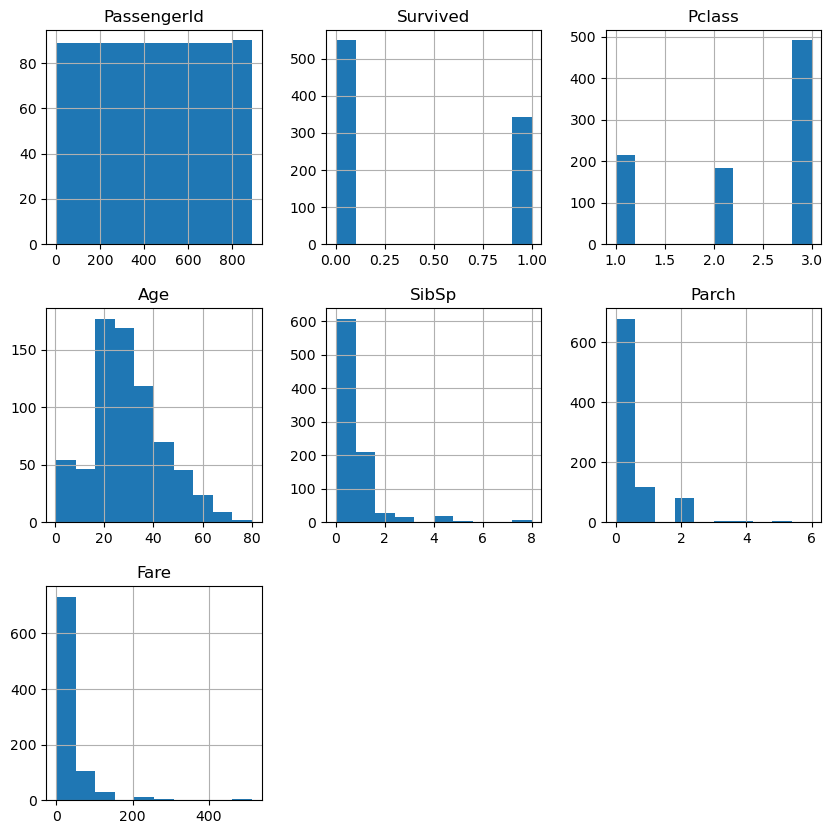

In [600]:
df.hist(figsize=(10,10))
plt.show()

<span style="color:#FF5F00"><b>AUFGABE 2:</b></span><br>
Überlegen Sie: Welche Aussagen können Sie aus den Histogrammen entnehmen? Wieviele Passagiere haben überlebt? Wie viele reisten in welcher Klasse? Wie alt waren die Passagiere im Schnitt? Reisten viele Passagiere alleine? Wie verteilten sich die Ticketpreise?

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 2:</b></span><br>

In [601]:
print("median:", float(df["Age"].median()))
print("mean:", float(df["Fare"].mean()))

median: 28.0
mean: 32.204207968574636


**Wieviele Passagiere haben überlebt?<br>**
Es haben ca. 550 Passagiere überlebt, ca. 340 haben es nicht geschafft.

**Wie viele reisten in welcher Klasse?<br>**
Es reisten ca. 210 Passagiere in der ersten, 190 in der zweiten und 500 in der dritten Klasse. Der Großteil der Reisenden reiste also in der dritten Klasse, mehr als alle Passagiere der ersten und zweiten Klasse zusammen.

**Wie alt waren die Passagiere im Schnitt?<br>**
Das durschnittliche Alter der Reisenden beträgt **29,7** , der Median liegt bei **28**. Die Werte liegen aber in einer Spanne zwischen 0 und 80 Jahren, der Großteil davon zwischen 20 und 40.

**Reisten viele Passagiere alleine?<br>**
Ja, ein Großteil der Passagiere **(> 600)** reist ohne Begleitung durch Eltern, Kinder, Ehepartner oder Geschwister. Einige reisten in Begleitung von einem/r Ehepartner\*in oder Geschwistern, ganz wenige auch mit zwei oder mehr. Ähnlich ist es auch bei der Anzahl begleitender Eltern/Kinder: von den Reisenden, die nicht alleine reisen, sind die meisten mit einem oder zwei Begleitern unterwegs.

**Wie verteilten sich die Ticketpreise?<br>**
Der größte Teil der Reisenden **(> 700)** bezahlte nur weniger als 50 €, ca. 150 Leute Zahlten Preise um die 100 €. Ganz wenige Fahrgäste (< 20) bezahlten über 200 € und 400 €.

<span style="color:#FF5F00"><b>AUFGABE 3:</b></span><br>

Eine Visualisierung des Anteils der Überlebenden zu einem Merkmal, z.B. zur Passagierklasse, könnte erste Hinweise auf ein gutes Modell liefern. Um dies einfach umzusetzen, ist die Bibliothek seaborn und dort der Befehl countplot sehr hilfreich. Schauen Sie in der Dokumentation von searborn nach und versuchen Sie es!

Tipp: Binden Sie die Bibliothek `seaborn` mit dem Kürzel `sns`ein und führen Sie im Anschluss den Befehl `sns.countplot(...)` aus. Eingabeparameter sind für `x` die Passagierklasse, für `hue` die Spalte mit dem Merkmal Überleben und für `data` der Datensatz. <br> Durch Ändern von `x='Pclass'` in ein anderes Merkmal können Sie dies auch für andere Merkmale tun. 
</div>

<Axes: xlabel='Pclass', ylabel='count'>

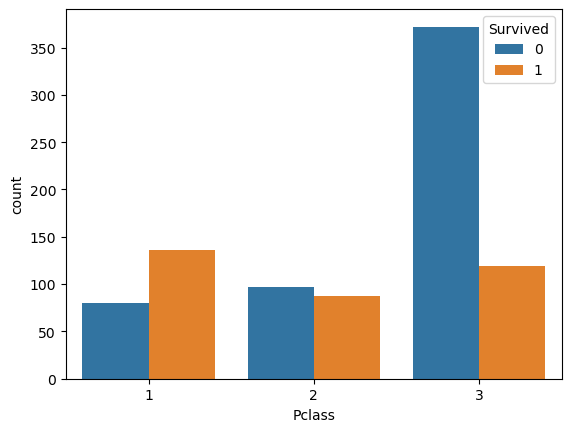

In [602]:
# Platz für Arbeitsauftrag
import seaborn as sns
sns.countplot(data=df ,x=df["Pclass"], hue=df["Survived"])

Aus dieser Darstellung zeigt sich bereits, dass Reisende der untersten Passagierklasse im Vergleich zu den beiden anderen Passagierklassen zu einem geringeren Anteil überlebt haben.

<div class="alert alert-block alert-warning">
<b>Ergebnissicherung:</b> <br>
    - Der Arbeitsbereich Datenverständnis dient dazu, sich einen Überblick über die vorliegenden Daten zu verschaffen. Dabei sollten die Daten in Hinblick auf ihre Eigenschaften und Qualität und die dadurch ggf. auftretenden Probleme für die Aufgabenstellung analysiert werden.
</div>

### Datenvorbereitung (Data preparation) <a name="kap3"></a>

Bei der Datenvorbereitung wird ein Datensatz so weit vorbereitet, dass er anschließend für die Modellierung genutzt werden kann. Dabei sind viele Aspekte zu beachten:
- Fehlende Daten werden ergänzt.
- Der Datentyp wird überprüft und ggf. geändert.
- Es werden die Merkmale ausgewählt, die Einfluss auf die Zielvariable haben. 
- ...

In [603]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Offenbar ist der Datensatz nicht vollständig. Eine Ergänzung der fehlenden Daten erscheint, gerade bei dem Merkmal `Cabin` aber schwierig. Dieser Punkt wird zunächst zurückgestellt und dann betrachtet, sobald die Merkmale für die spätere Analyse ausgewählt wurden. 

Daten mit numerischem Typ können von Python besser analysiert und verarbeitet werden, deshalb sollen zunächst alle Merkmale vom Typ `object` betrachtet werden, um zu sehen, ob sie in Zahlen umgewandelt werden können: 

- Beim Merkmal Namen ist dies nicht sinnvoll.
- Das Merkmal `Sex` könnten durch `male`='männlich' mit 0 und `female`='weiblich' mit 1 umkodiert werden. 
- Das Merkmal `Ticket` beinhaltet eine unverständliche Buchstaben-Nummern-Kombination und bleibt deswegen unverändert. 
- Das Merkmal `Cabin` enthält nur wenige Daten und ist deswegen uninteressant. 
- Das Merkmal `Embarked` könnte mit Hilfe von Zahlen umkodiert werden, wegen des geringen zu erwartenden Einflusses wird dies zunächst nicht durchgeführt. 

In [604]:
df.loc[df.Sex =='male', 'Sex']='0.0'
df.loc[df.Sex =='female', 'Sex']='1.0'

Die Änderungen werden durch die Betrachtung der Daten überprüft: 

In [605]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0.0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1.0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1.0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1.0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0.0,35.0,0,0,373450,8.0500,NaN,S


In [606]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Das Geschlecht ist immer noch vom Typ `object`. 

<span style="color:#FF5F00"><b>AUFGABE 4:</b></span><br>
    
Nutzen Sie die Dokumentation von Python oder eine Suchmaschine dazu, herauszufinden, wie sich der Datentyp der Spalte `df['Sex']` in `float` umwandeln lässt. Wenden Sie den passenden Befehl anschließend an. 
    
Tipp: Eine Möglichkeit ist in der Pandas Bibliothek zu finden. 
</div>

In [607]:
# Platz für Arbeitsauftrag
df["Sex"] = df["Sex"].apply(pd.to_numeric)

Die nachfolgende Ausgabe zeigt, dass das Vorgehen erfolgreich war. 

In [608]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    float64
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(3), int64(5), str(4)
memory usage: 83.7 KB


### 3.1 Aufteilung in Trainings- und Testdatensatz <a name="kap31"></a>

Beim überwachten Lernen wird der Datensatz in Trainings- und Testdatensatz aufgeteilt. Der Testdatensatz soll völlig unabhängig von allen späteren Entscheidungen sein, um damit die Güte der Vorhersage testen können. Daher wird diese Trennung üblicherweise vor der Merkmalsauswahl vorgenommen.

Im folgenden Abschnitt wird der Datensatz aufgeteilt. Die Größe des Testdatensatzsatzes soll 30 % betragen (`test_size=0.3`). Mit `random_state=0` wird sichergestellt, dass immer die gleichen 30% Testdaten ausgewählt werden (die Ergebnisse des Modells fallen sonst bei jeder Durchführung etwas anders aus), `stratify` sorgt dafür, dass nach der Teilung in Trainings- und Testmenge die Verteilung in den beiden Mengen der der Ausgangsmenge entspricht, das bedeutet der Anteil der Überlebenden ist in beiden Mengen gleich. 

An dieser Stelle wird zum ersten Mal die Bibliothek sklearn benutzt. Sie ist die beliebteste Bibliothek für maschinelles Lernen in Python und enthält viele wichtigen Befehle aus diesem Bereich.

In [609]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.3, random_state=0, stratify = df['Survived'])
print(train_set)

     PassengerId  Survived  Pclass                                  Name  Sex  \
231          232         0       3              Larsson, Mr. Bengt Edvin  0.0   
836          837         0       3                      Pasic, Mr. Jakob  0.0   
639          640         0       3            Thorneycroft, Mr. Percival  0.0   
389          390         1       2                 Lehmann, Miss. Bertha  1.0   
597          598         0       3                   Johnson, Mr. Alfred  0.0   
..           ...       ...     ...                                   ...  ...   
131          132         0       3        Coelho, Mr. Domingos Fernandeo  0.0   
490          491         0       3  Hagland, Mr. Konrad Mathias Reiersen  0.0   
838          839         1       3                       Chip, Mr. Chang  0.0   
48            49         0       3                   Samaan, Mr. Youssef  0.0   
80            81         0       3                  Waelens, Mr. Achille  0.0   

      Age  SibSp  Parch    

In [610]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 623 entries, 231 to 80
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  623 non-null    int64  
 1   Survived     623 non-null    int64  
 2   Pclass       623 non-null    int64  
 3   Name         623 non-null    str    
 4   Sex          623 non-null    float64
 5   Age          496 non-null    float64
 6   SibSp        623 non-null    int64  
 7   Parch        623 non-null    int64  
 8   Ticket       623 non-null    str    
 9   Fare         623 non-null    float64
 10  Cabin        143 non-null    str    
 11  Embarked     621 non-null    str    
dtypes: float64(3), int64(5), str(4)
memory usage: 63.3 KB


### 3.2 Erste Merkmalsauswahl <a name="kap32"></a>

Zur Datenvorbereitung gehört die Entscheidung, welche Merkmale für die Modellierung betrachtet werden. So hat beispielsweise der Name der Reisenden offensichtlich keinen Einfluss auf das Überleben.

Bei anderen Merkmalen stellt sich die Frage nach dem Einfluss aber:
- Hat das Alter der Reisenden Einfluss auf ihren Überlebenswillen?
- Haben Reisende mit vielen Angehörigen an Bord sich bemüht, sie zu retten und dabei das eigene Überleben riskiert?
- Hat das Geschlecht Einfluss auf das Überleben? Haben sich Männer zuerst in die Rettungsboote gesetzt oder wurde nach dem Grundsatz "Frauen und Kinder zuerst" gehandelt?

Eine Idee für den Einfluss eines numerischen Merkmals auf ein anderes gibt der Korrelationskoeffizient.
Der Korrelationskoeffizient wird zwischen zwei Merkmalen berechnet und sein Wert liegt immer zwischen -1 und 1. Dabei bedeutet ein Wert nahe 0, dass zwei Merkmale sich gegenseitig nicht beeinflussen. Ein positiver Wert bedeutet, dass bei steigenden Werten des einen Merkmals auch die Werte des anderen Merkmals steigen. Je näher der Korrelationskoeffizient an 1 liegt, desto besser lässt sich das Verhältnis anhand einer Geraden mit positiver Steigung darstellen. Ein negativer Korrelationskoeffizient sagt aus, dass bei steigenden Werten des einen Merkmals die Werte des anderen Merkmals fallen. Je näher der Wert an -1 liegt, desto besser lässt sich das Verhältnis anhand einer Geraden mit negativer Steigung darstellen.

Ein Überblick über die Korrelationskoeffizienten lässt sich mit einem einfachen Befehl erzeugen. 

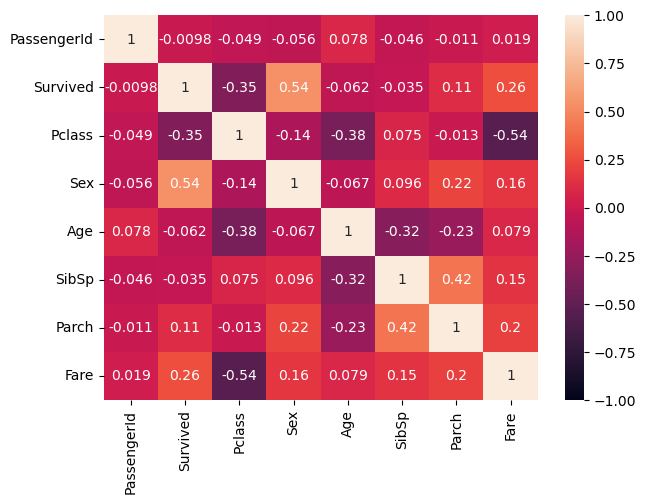

In [611]:
import seaborn as sns
corr_matrix = train_set.corr(numeric_only=True)
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1)
plt.show()

<span style="color:#FF5F00"><b>AUFGABE 5:</b></span><br>
<b>Arbeitsauftrag:</b> 
Überlegen Sie: welche Merkmale scheinen den größten Einfluss auf das Überleben auf der Titianic gehabt zu haben? 
</div>

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 5:</b></span><br>

Die erzeugte Heatmap zeigt Korrelationen von numerischen Werten als quadratische Matrix. Die einzelnen Felder werden basierend auf ihrem Korrelationswert eingefärbt. Je näher ein Wert an **0** kommt, desto weniger korrelieren Werte der Spalte mit den Werten der Zeile. 

Unter Betrachtung der Spalte/Zeile `"Survived"` stechen drei Korrelationen besonders ins Auge:

- Pclass (Korrelation zu `"Survived"`: -0,35)
- Sex (Korrelation zu `"Survived"`: 0,54)
- Fare (Korrelation zu `"Survived"`: 0,26)

Das erweckt den Anschein, dass das Geschlecht (*Sex*) sowie die finanzielle Situation der Reisenden (*Fare* + *Pclass*) den größten Einfluss auf das Überleben hatten.

Zunächst wollen wir für die Modellierung deswegenausschließlich die Merkmale `Sex` und `Pclass` (und natürlich `Survived` als Zielvariable) betrachten. Die Auswahl wird im nächsten Schritt durchgeführt, das Zielmerkmal wird als `y` (abhängige Variable), die Menge aus Geschlecht und Passagierklasse als `X` (unabhängige Variable) gespeichert: 

In [612]:
X_train=train_set[['Sex', 'Pclass']]
X_train.info()
y_train=train_set[['Survived']]

X_test=test_set[['Sex', 'Pclass']]
X_test.info()
y_test=test_set[['Survived']]

<class 'pandas.DataFrame'>
Index: 623 entries, 231 to 80
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sex     623 non-null    float64
 1   Pclass  623 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 14.6 KB
<class 'pandas.DataFrame'>
Index: 268 entries, 421 to 607
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sex     268 non-null    float64
 1   Pclass  268 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 6.3 KB


Die Ansicht zeigt, dass bezüglich der ausgewählten Merkmale keine `NaN` Einträge vorhanden sind, deshalb kann mit der Modellierung begonnen werden. 

<div class="alert alert-block alert-warning">
<b>Ergebnissicherung:</b> <br>
    - Der Arbeitsbereich Datenvorbereitung dient dazu, den Datensatz so zu bereinigen und vorzubereiten, dass mit diesem die Modellierung vorgenommen werden kann.
</div>

### Modellierung <a name="kap4"></a>

Nun wird mit Hilfe der ausgewählten Merkmale aus den Trainingsdaten ein Modell zur Vorhersage des Überlebens der Reisenden erstellt. Das Modell, welches hier genutzt wird, ist ein Entscheidungsbaum (Decision Tree). 

Die folgende Zelle importiert das Modul zur Nutzung von Entscheidungbäumen und iniziiert dann einen Baum mit Tiefe 2 (`max_depth = 2`), es dürfen also zwei Unterscheidungsebenen erstellt werden.

In [613]:
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(max_depth = 2)
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [614]:
tree_clf.predict([[1,3]])

/Users/feli/anaconda3/envs/wikisys/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

Um das Modell zu visualisieren, wird mit dem folgenden Befehl der entstandene Baum ausgegeben.

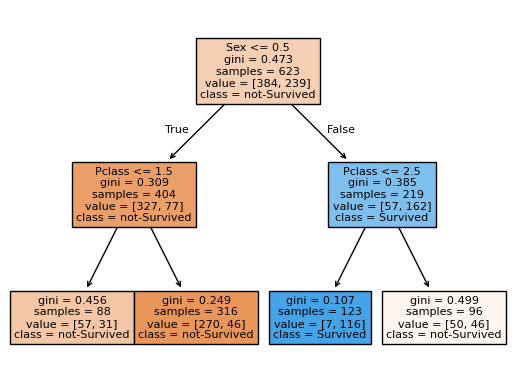

In [615]:
from sklearn import tree
tree.plot_tree(tree_clf, feature_names = X_train.columns, class_names=['not-Survived', 'Survived'], filled=True); 

Das erste Modell wurde erfolgreich erzeugt. Die Visualisierung zeigt eine Entscheidung auf zwei Entscheidungsebenen, die erste nach dem Geschlecht, die zweite nach der Passagierklasse. Die Ausgabe (und Farbe) auf der untersten Ebene zeigen die Art der Klassifikation an.

<div class="alert alert-block alert-warning">
<b>Ergebnissicherung:</b> <br>
    - Der Arbeitsbereich Modellierung dient dazu, die für den Datensatz geeigneten Methoden des Data Minings zu ermitteln und anzuwenden. Dabei werden die Parameter der Modelle optimiert und häufig verschiedene Modelle erstellt und verglichen.
</div>

### Modellgüte <a name="kap41"></a>

Ein erster Ansatz, um die Güte eines Modells einzuschätzen, ist die Trefferquote des Ziel-Merkmals bezüglich der Trainingsdaten und bezüglich der Testdaten. Dies wird in der folgenden Zelle berechnet:

In [616]:
print(tree_clf.score(X_train, y_train))
print(tree_clf.score(X_test, y_test))

0.7913322632423756
0.7761194029850746


<span style="color:#FF5F00"><b>AUFGABE 6:</b></span><br>
    
Eine weitere Möglichkeit, die Güte eines Modells zu überprüfen ist die Konfusionsmatrix. Um diese zu nutzen, ist die Funktion `confusion_matrix` aus dem metrics Modul sehr hilfreich. Schauen Sie in der Dokumentation von sklearn nach und versuchen Sie es!

Tipp: Importieren Sie aus der Bibliothek `sklearn` das Modul `metrics` und nutzen Sie dann den Befehl `metrics.confusion_matrix(...)` mit der durch das Modell ermittelten Klasse und der tatsächlichen Klasse als Eingabeparametern.<br>
    
Frage: Was könnten die Einträge der ausgegebenen Matrix bedeuten?   
</div>

In [617]:
# Platz für Arbeitsauftrag
from sklearn import metrics
metrics.confusion_matrix(
    y_true=y_test,
    y_pred=tree_clf.predict(X_test)
)

array([[163,   2],
       [ 58,  45]])

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 6:</b></span><br>

Die Confusionmatrix zeigt einen hohen Anteil an **True Negatives** (163) und **True Positives**(45), was für eine Recht hohe Genauigkeit spricht.

Sehr auffällig ist die extrem kleine Anzahl an **False Negatives** (2). Zusammen mit der moderaten Anzahl an **False Positives** (58) könnte das bedeuten, dass das Modell dazu tendiert, den Reisenden schlechtere Überlebenschancen vorherzusagen, als sie tatsächlich hatten. Es schätzt viel öfter *"nicht überleben"* als *"überleben"*.

Die Konfusionsmatrix gibt uns genauer Erkenntnisse über die Art der falschen Vorhersagen.

Das erste Modell könnte nun herausgegeben werden, es ist aber sinnvoller, noch einmal die vorhergehenden Schritte durchzugehen und zu überlegen, ob es mit einem neuen Durchlauf noch verbessert werden kann.


<div class="alert alert-block alert-warning">
<b>Ergebnissicherung:</b> <br>
    - Der Arbeitsbereich Evaluation dient dazu, die erstellten Modelle qualitativ zu bewerten, diese mit der Aufgabenstellung abzugleichen und das beste Modell auszuwählen.
</div>

#### Iteration zu den vorhergehenden Schritten <a name="kap42"></a>

Bei diesem Schritt handelt es sich nicht um einen eigenen Arbeitsbereich, sondern vielmehr um die systematische Wiederholung der vorhergehenden Arbeitsbereiche für eine potentielle Verbesserung des Modells, beispielsweise anhand folgender Fragen: 
- Sollte versucht werden, fehlende Werte durch geschätzte Werte zu ersetzen, um nicht so viele Daten herauslöschen zu müssen?
- Können andere oder mehr Merkmale verwendet werden, um das Modell zu erstellen? 
- Kann eine Veränderung der Modellparameter zu einem verbesserten Modell führen? 


<span style="color:#FF5F00"><b>AUFGABE 7:</b></span><br>
    
Versuchen Sie, mit Hilfe der Data Frame Methode `df['Spaltenname'].mean()` und dem Anzeiger `df.loc` die fehlenden Werte in  `Age` und `Fare` durch mittelwerte zu ersetzen.

Bauen Sie nun einen Entscheidungsbau, der auchdie Merkmale `Parch`, `Age` und `Fare` für die Modellierung betrachtet.
Der Entscheidungsbaum soll sich bis zu einer Tiefe von 3 aufbauen. 

Zu Ihrer Hilfe findet sich unten schon ein Teil des Codes - Sie müssen nur die Punkte ersetzen.

</div>


In [618]:
df.loc[df['Age'].isna(), 'Age'] = df['Age'].mean()
df.loc[df['Fare'].isna(), 'Fare'] = df['Fare'].mean()


In [619]:
train_set, test_set = train_test_split(df, test_size=0.3, random_state=0, stratify = df['Survived'])
X_train = train_set[['Sex', 'Pclass', 'Parch', 'Age', 'Fare']]
y_train = train_set['Survived']

X_test = test_set[['Sex', 'Pclass', 'Parch', 'Age', 'Fare']]
y_test = test_set['Survived']

X_train.info()

<class 'pandas.DataFrame'>
Index: 623 entries, 231 to 80
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sex     623 non-null    float64
 1   Pclass  623 non-null    int64  
 2   Parch   623 non-null    int64  
 3   Age     623 non-null    float64
 4   Fare    623 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 29.2 KB


In [620]:
tree_clf = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
    min_samples_leaf=10 # reduce overfitting
)  
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

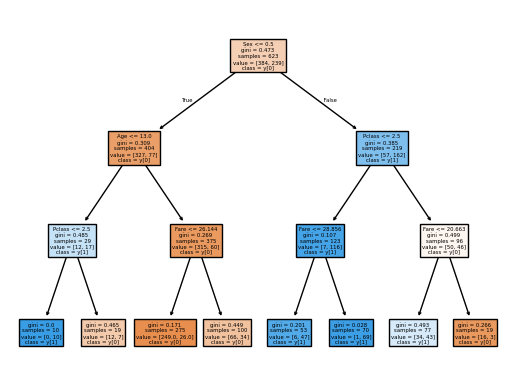

In [621]:
tree.plot_tree(tree_clf, feature_names = X_train.columns, class_names=True, filled=True);

In [622]:
print(tree_clf.score(X_train, y_train))
print(tree_clf.score(X_test, y_test))

0.8218298555377207
0.8246268656716418


Das Modell hat sich durch diese Schritte ein wenig verbessert! 
Es kann beobachtet werden, dass sich ein Modell manchmal schon durch schlichtes Ausprobieren optimieren lässt.

<span style="color:#FF5F00"><b>AUFGABE 8:</b></span><br>

Nutzen Sie die nachfolgend vorgegebenen Bausteine, um mit der Auswahl der Merkmale und der Tiefe des Baums zu experimentieren, indem Sie die Bausteine einkommentieren und mit Parametern befüllen. Beschreiben Sie ihr finales Ergebnis. Halten Sie alle Vorgehensweisen und Parameter fest. Versuchen Sie, die Güte Ihres Modells so weit wie irgend möglich zu optimieren. <br>
</div>



In [623]:
# Baustein zum Trennen von Trainingsdaten und Testdaten
train_set, test_set = train_test_split(df, test_size=0.3, random_state=69, stratify = df['Survived'])

# replace mean values with median (no big effect)
df.loc[df['Fare'] == df['Fare'].mean(), 'Fare'] = df['Fare'].median()

X_train=train_set[['Sex', 'Pclass', 'Fare']]
y_train=train_set[['Survived']]
X_train.info()

X_test=test_set[['Sex', 'Pclass', 'Fare']]
y_test=test_set[['Survived']]
X_test.info()

<class 'pandas.DataFrame'>
Index: 623 entries, 592 to 8
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sex     623 non-null    float64
 1   Pclass  623 non-null    int64  
 2   Fare    623 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 19.5 KB
<class 'pandas.DataFrame'>
Index: 268 entries, 808 to 171
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sex     268 non-null    float64
 1   Pclass  268 non-null    int64  
 2   Fare    268 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 8.4 KB


0.8057784911717496
0.8134328358208955


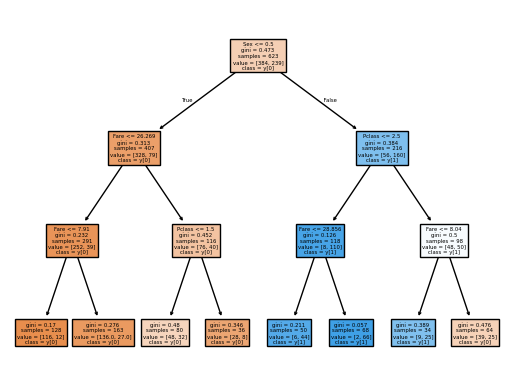

In [626]:
# Baustein zum Fitten und Ausgeben des Modells und seiner Güte
tree_clf_v2 = DecisionTreeClassifier( 
    max_depth=3,
    random_state=42,
    min_samples_leaf=28,
    min_samples_split=30,
    criterion="gini"
)  
tree_clf_v2.fit(X_train, y_train)
tree.plot_tree(tree_clf_v2, feature_names = X_train.columns, class_names=True, filled=True) 
print(tree_clf_v2.score(X_train, y_train))
print(tree_clf_v2.score(X_test, y_test))

In [625]:
metrics.confusion_matrix(
    y_true=y_test,
    y_pred=tree_clf_v2.predict(X_test)
)

array([[158,   7],
       [ 43,  60]])

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 8:</b></span><br>